In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new/control_ny_1'

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

all_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = os.listdir(file_path)
all_crawls.remove('.DS_Store')
all_crawls

['2025-12-12 13:47:36',
 '2025-12-11 22:31:57',
 '2025-12-12 08:39:20',
 '2025-12-12 03:32:00']

### Merging and preprocessing

In [5]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():

        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            # if both comments and timestamps files are present
            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:

                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                # this particular comment is just ' '. so adding it manually.
                id_user_mapping = {
                    'DRVQXcWAaaw': 'authoryuccaharris',
                    'DSBZZEcgL4D': 'mafia__460mafia_', 
                    'DSBm_S8gC1p': 'grimreaper3716',
                    'DRYdTZHjT-E': 'danieleichenlaub',
                    'DSARqDnEhPJ': 'amadeoedgardof',
                    'DR_mqpKEr01': 'amadeoedgardof',
                    'DSC60BKkrYV': 'amadeoedgardof',
                    'DR5O3P_jycm': 'dottyeroth',
                    'DSCrwGuDxUR': 'treqpimento_',
                    'DSEn813Eo5Q': 'amadeoedgardof'

                }

                if id_ in id_user_mapping:
                    if id_user_mapping[id_] in comments:
                        idx = comments.index(id_user_mapping[id_])
                        comments = comments[:idx+1] + [' '] + comments[idx+1:]

                # mapping usernames and comments to timestamps
                comments_map = {}

                # checking if comments (username + comment) and timestamps are of same length 
                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes} # TODO: check if likes here is correct
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    # if this happens, its mostly happening since a comment is empty string ''
                    print(f'comemnts-timestamps length mismatch', account, id_, crawl)
            else:
                # only comments file is present
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)
                if len(comments) != 0:
                    if id_ == 'DSC60BKkrYV':
                        caption, comments, likes = None, [], None
                    else:
                        print('no timestamp file and len(comments) != 0', id_, account, crawl, len(comments))
                    
                    # if this happens its usually to do more cleaning of comements

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

In [6]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

2025-12-12 13:47:36: (1081, 7)
2025-12-11 22:31:57: (1099, 7)
2025-12-12 08:39:20: (1101, 7)
2025-12-12 03:32:00: (1102, 7)


In [7]:
for crawl, df in dfs.items():
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [8]:
# merging all dfs

merged_df = dfs['2025-12-12 13:47:36'].copy()

for crawl, df in dfs.items():
    if crawl == '2025-12-12 13:47:36':
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])

2025-12-11 22:31:57
2025-12-12 08:39:20
2025-12-12 03:32:00


In [9]:
# remove urls that have less than 10 comments

urlids = merged_df['urlid'].unique().tolist()
donotremove_urls = set()
for urlid in urlids:
    temp = merged_df[merged_df['urlid'] == urlid]
    num_rows = temp['comment_num'].max()
    if num_rows <= 8:
        continue
    else:
        donotremove_urls.add(urlid)

merged_df = merged_df[merged_df['urlid'].isin(donotremove_urls)]

In [10]:
# limiting to top 10 comments
merged_df = merged_df[merged_df['comment_num'] <= 9]
merged_df.shape

(760, 11)

In [11]:
merged_df

,account,urlid,comment_num,2025-12-12 13:47:36_comment,2025-12-12 13:47:36_timestamp,2025-12-11 22:31:57_comment,2025-12-11 22:31:57_timestamp,2025-12-12 08:39:20_comment,2025-12-12 08:39:20_timestamp,2025-12-12 03:32:00_comment,2025-12-12 03:32:00_timestamp
0,accesshollywood,DSB-0hjkQNx,0,"(ericalex06, 😂😂😂😂👏👏)",2025-12-09T23:29:19.000Z,"(ericalex06, 😂😂😂😂👏👏)",2025-12-09T23:29:19.000Z,"(ericalex06, 😂😂😂😂👏👏)",2025-12-09T23:29:19.000Z,"(ericalex06, 😂😂😂😂👏👏)",2025-12-09T23:29:19.000Z
1,accesshollywood,DSB-0hjkQNx,1,"(mindi.bro, Pickleball?)",2025-12-09T05:42:03.000Z,"(timothee_chalamet_mx, 🔥❤️😍)",2025-12-10T04:50:12.000Z,"(mindi.bro, Pickleball?)",2025-12-09T05:42:03.000Z,"(timothee_chalamet_mx, 🔥❤️😍)",2025-12-10T04:50:12.000Z
2,accesshollywood,DSB-0hjkQNx,2,"(timothee_chalamet_mx, 🔥❤️😍)",2025-12-10T04:50:12.000Z,"(mindi.bro, Pickleball?)",2025-12-09T05:42:03.000Z,"(timothee_chalamet_mx, 🔥❤️😍)",2025-12-10T04:50:12.000Z,"(mindi.bro, Pickleball?)",2025-12-09T05:42:03.000Z
3,accesshollywood,DSB-0hjkQNx,3,"(growing_up_with_timothee, Definitely 😍🧡)",2025-12-09T16:41:31.000Z,"(debmarie5, Why so much orange on him)",2025-12-11T02:42:11.000Z,"(growing_up_with_timothee, Definitely 😍🧡)",2025-12-09T16:41:31.000Z,"(growing_up_with_timothee, Definitely 😍🧡)",2025-12-09T16:41:31.000Z
4,accesshollywood,DSB-0hjkQNx,4,"(persona_tiffany, I love it 👏👏)",2025-12-09T19:21:57.000Z,"(growing_up_with_timothee, Definitely 😍🧡)",2025-12-09T16:41:31.000Z,"(persona_tiffany, I love it 👏👏)",2025-12-09T19:21:57.000Z,"(debmarie5, Why so much orange on him)",2025-12-11T02:42:11.000Z
...,...,...,...,...,...,...,...,...,...,...,...
1095,thegradecricketer,DSERcMKEs-k,5,"(benparnhamofficial, Bluey is all time 👌)",2025-12-10T05:32:13.000Z,"(benparnhamofficial, Bluey is all time 👌)",2025-12-10T05:32:13.000Z,"(perrinfaerch, Bluey is one of the greatest sh...",2025-12-10T15:45:30.000Z,"(benparnhamofficial, Bluey is all time 👌)",2025-12-10T05:32:13.000Z
1096,thegradecricketer,DSERcMKEs-k,6,"(dst_13, Bluey vs Peppa Pig is like Smudge vs ...",2025-12-10T04:18:24.000Z,"(dst_13, Bluey vs Peppa Pig is like Smudge vs ...",2025-12-10T04:18:24.000Z,"(dst_13, Bluey vs Peppa Pig is like Smudge vs ...",2025-12-10T04:18:24.000Z,"(dst_13, Bluey vs Peppa Pig is like Smudge vs ...",2025-12-10T04:18:24.000Z
1097,thegradecricketer,DSERcMKEs-k,7,"(perrinfaerch, Bluey is one of the greatest sh...",2025-12-10T15:45:30.000Z,"(perrinfaerch, Bluey is one of the greatest sh...",2025-12-10T15:45:30.000Z,"(benparnhamofficial, Bluey is all time 👌)",2025-12-10T05:32:13.000Z,"(perrinfaerch, Bluey is one of the greatest sh...",2025-12-10T15:45:30.000Z
1098,thegradecricketer,DSERcMKEs-k,8,"(jacobdawkins, Get Rusty as opener and Tiny se...",2025-12-10T03:04:04.000Z,"(koitis.jw, This is some of the most elite cha...",2025-12-10T06:16:26.000Z,"(koitis.jw, This is some of the most elite cha...",2025-12-10T06:16:26.000Z,"(koitis.jw, This is some of the most elite cha...",2025-12-10T06:16:26.000Z


In [12]:
temp_df = get_chronological_order_comments(merged_df, all_urls, all_crawls)
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [13]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,comment_num,2025-12-12 13:47:36_comment,2025-12-11 22:31:57_comment,2025-12-12 08:39:20_comment,2025-12-12 03:32:00_comment,chronological_comment
0,accesshollywood,DSB-0hjkQNx,0,"(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(debmarie5, Why so much orange on him)"
1,accesshollywood,DSB-0hjkQNx,1,"(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)"
2,accesshollywood,DSB-0hjkQNx,2,"(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(ericalex06, 😂😂😂😂👏👏)"
3,accesshollywood,DSB-0hjkQNx,3,"(growing_up_with_timothee, Definitely 😍🧡)","(debmarie5, Why so much orange on him)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(taosphotogirl22, Clearly, yes, we do.)"
4,accesshollywood,DSB-0hjkQNx,4,"(persona_tiffany, I love it 👏👏)","(growing_up_with_timothee, Definitely 😍🧡)","(persona_tiffany, I love it 👏👏)","(debmarie5, Why so much orange on him)","(persona_tiffany, I love it 👏👏)"


In [14]:
merged_df.shape

(821, 8)

In [15]:
# merged_df.to_excel('temp.xlsx')

### Plotting Differences

In [16]:
merged_df.head()

,account,urlid,comment_num,2025-12-12 13:47:36_comment,2025-12-11 22:31:57_comment,2025-12-12 08:39:20_comment,2025-12-12 03:32:00_comment,chronological_comment
0,accesshollywood,DSB-0hjkQNx,0,"(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(debmarie5, Why so much orange on him)"
1,accesshollywood,DSB-0hjkQNx,1,"(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)"
2,accesshollywood,DSB-0hjkQNx,2,"(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(ericalex06, 😂😂😂😂👏👏)"
3,accesshollywood,DSB-0hjkQNx,3,"(growing_up_with_timothee, Definitely 😍🧡)","(debmarie5, Why so much orange on him)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(taosphotogirl22, Clearly, yes, we do.)"
4,accesshollywood,DSB-0hjkQNx,4,"(persona_tiffany, I love it 👏👏)","(growing_up_with_timothee, Definitely 😍🧡)","(persona_tiffany, I love it 👏👏)","(debmarie5, Why so much orange on him)","(persona_tiffany, I love it 👏👏)"


In [17]:
crawl1 = 'chronological'
crawl2 = '2025-12-12 13:47:36'

temp_df = merged_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, all_urls)

division by zero espn DSEVBjZAOdU 0 0


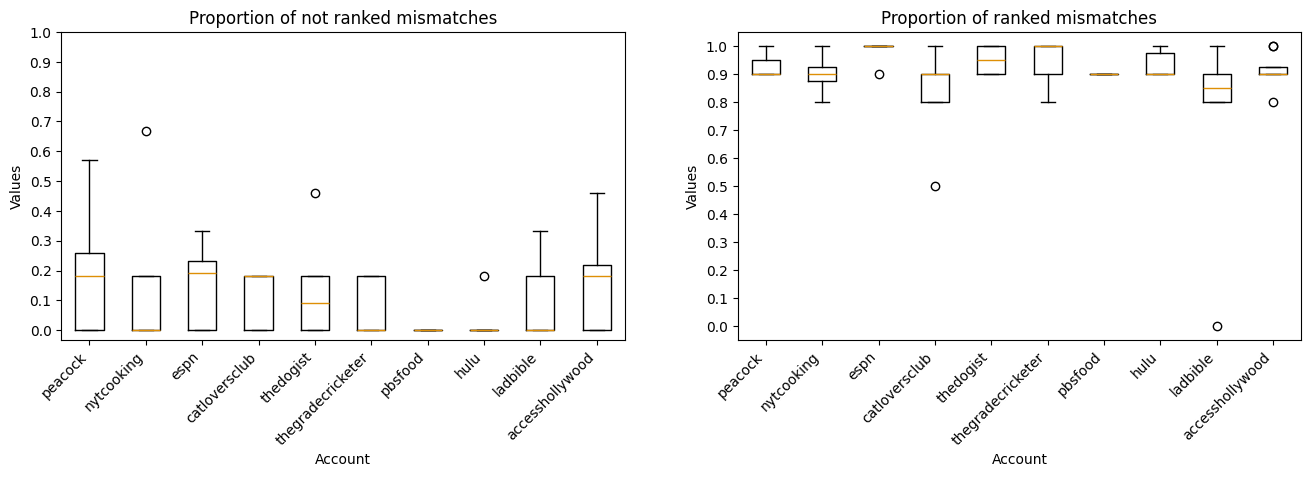

In [18]:
accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

In [19]:
mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in ['chronological'] + all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = merged_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, all_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

division by zero espn DSEVBjZAOdU 0 0
division by zero espn DSEVBjZAOdU 0 0


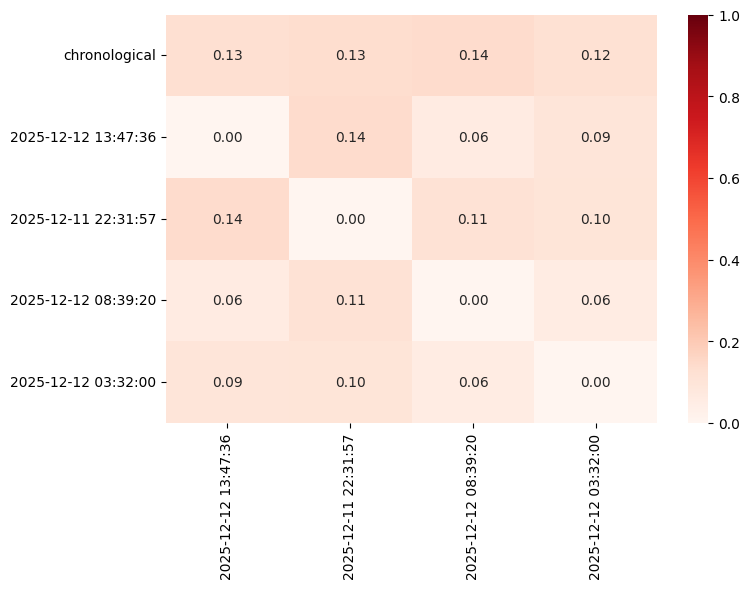

In [20]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(mismatch_no_rank_df, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

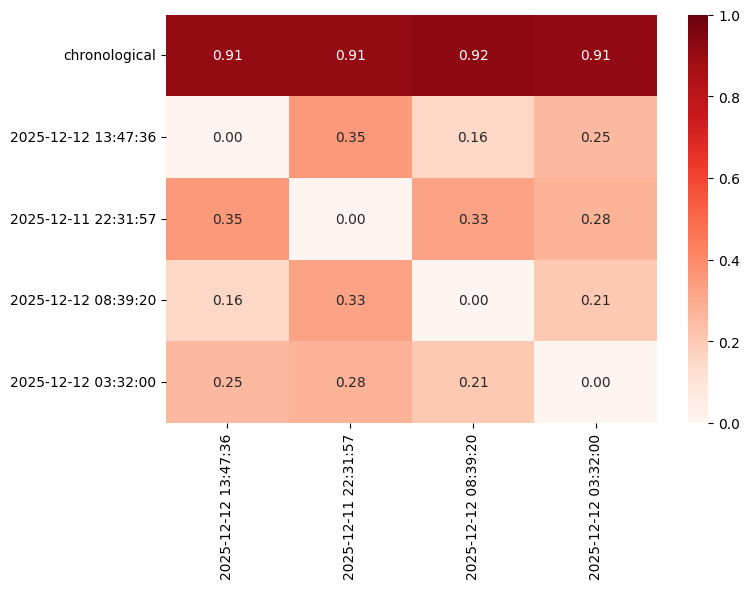

In [21]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(mismatch_rank_df, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

#### Old graphs

In [ ]:
# col1 = 'chronological_comment'
# col2 = '2025-12-07 15:37:20_comment'
# col3 = '2025-12-07 20:32:04_comment'
# col4 = '2025-12-08 01:32:00_comment'
# col5 = '2025-12-08 06:32:00_comment'

# cols = [col1, col2, col3, col4, col5]

# codes = []
# for idx, x in zip(merged_df.index, zip(*(merged_df[c] for c in cols))):

#     temp_code = []
#     for i, a in enumerate(x):
#         if pd.isna(a):
#             code = -1
#         else:
#             acc_comments = []
            
#             if i == 0:
#                 remove_col = col1
#             elif i == 1:
#                 remove_col = col2
#             elif i == 2:
#                 remove_col = col3
#             elif i == 3:
#                 remove_col = col4
#             elif i == 4:
#                 remove_col = col5

#             for c in cols:
#                 if c == remove_col:
#                     continue
#                 if c == col1:
#                     continue
#                 acc = merged_df.loc[idx, 'account']
#                 url = merged_df.loc[idx, 'urlid']
#                 acc_comments += merged_df[(merged_df['account'] == acc) & (merged_df['urlid'] == url)][c].dropna().unique().tolist() 

#             if a in set(acc_comments):
#                 code = 0
#             else:
#                 code = 1

#         temp_code.append(code)
#     codes.append(temp_code)

# codes = np.array(codes)

# max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
# num_groups = max_code + 1

# base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
# colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
# cmap = ListedColormap(colors)

# bounds = np.arange(-1.5, num_groups + 0.5, 1)
# norm = BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(6, 6))

# sns.heatmap(
#     codes,
#     annot=False,
#     cmap=cmap,
#     norm=norm,
#     vmin=-1,
#     vmax=max_code,
#     cbar=True,                      
#     linewidths=0,
#     yticklabels=False,
#     xticklabels=[c.replace('_comment', '') for c in cols],
#     ax=ax
# )

# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# cbar = ax.collections[0].colorbar
# cbar.set_ticks([-1, 0, 1])
# cbar.set_ticklabels([
#     "-1",
#     "0",
#     "1",
# ])

# # optional: add dotted separators for groups (your urlid trick)
# # indices = merged_df["urlid"].drop_duplicates().index
# # for y in indices:
# #     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

# plt.tight_layout()
# plt.show()


In [ ]:
# cols = [col1, col2, col3, col4, col5]
# key_cols = ["account", "urlid"]

# group_comments = {}
# for key, g in merged_df.groupby(key_cols, sort=False):
#     group_comments[key] = {
#         col: set(g[col].dropna())
#         for col in cols
#     }

# overall_not_covered = pd.DataFrame(index=cols, columns=cols, dtype=float)

# for c1 in cols:
#     for c2 in cols:
#         if c1 == c2:
#             overall_not_covered.loc[c1, c2] = 0.0
#             continue

#         total = 0
#         not_covered = 0

#         for key, d in group_comments.items():
#             s1 = d[c1]
#             s2 = d[c2]
#             if not s1:
#                 continue

#             total += len(s1)
#             not_covered += len(s1 - s2)

#         overall_not_covered.loc[c1, c2] = not_covered / total if total else 0.0



# fig, ax = plt.subplots(figsize=(8, 6))

# im = ax.imshow(
#     overall_not_covered.values,
#     aspect='auto',
#     cmap='Reds',
#     vmin=0, vmax=1
# )

# ax.set_xticks(range(len(cols)))
# ax.set_yticks(range(len(cols)))
# ax.set_xticklabels(cols, rotation=45, ha='right')
# ax.set_yticklabels(cols)

# for i in range(len(cols)):
#     for j in range(len(cols)):
#         ax.text(j, i, f"{overall_not_covered.iloc[i, j]:.2f}",
#                 ha='center', va='center', fontsize=8)

# cbar = fig.colorbar(im, ax=ax, cmap='Blues')
# cbar.set_label('Proportion of False (mismatch)')

# plt.tight_layout()
# plt.show()


In [ ]:
# col1 = 'chronological_comment'
# col2 = '2025-12-07 15:37:20_comment'
# col3 = '2025-12-07 20:32:04_comment'
# col4 = '2025-12-08 01:32:00_comment'
# col5 = '2025-12-08 06:32:00_comment'

# cols = [col1, col2, col3, col4, col5]

# codes = []
# for x in zip(*(merged_df[c] for c in cols)):
#     present_already = []
#     temp_code = []
#     for a in x:
#         if pd.isna(a):
#             c = -1
#         else:
#             if a not in present_already:
#                 c = len(present_already)
#                 present_already.append(a)
#             else:
#                 c = present_already.index(a)
#         temp_code.append(c)
#     codes.append(temp_code)

# codes = np.array(codes)

# max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
# num_groups = max_code + 1

# base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
# colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
# cmap = ListedColormap(colors)

# bounds = np.arange(-1.5, num_groups + 0.5, 1)
# norm = BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(6, 6))

# sns.heatmap(
#     codes,
#     annot=False,
#     cmap=cmap,
#     norm=norm,
#     vmin=-1,
#     vmax=max_code,
#     cbar=False,                      
#     linewidths=0,
#     yticklabels=False,
#     xticklabels=[c.replace('_comment', '') for c in cols],
#     ax=ax
# )

# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # optional: add dotted separators for groups (your urlid trick)
# # indices = merged_df["urlid"].drop_duplicates().index
# # for y in indices:
# #     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

# plt.tight_layout()
# plt.show()


In [ ]:
# false_ratio = pd.DataFrame(index=cols, columns=cols, dtype=float)

# for c1 in cols:
#     for c2 in cols:
#         if c1 == c2:
#             false_ratio.loc[c1, c2] = 0.0
#         else:
#             comp = merged_df[c1] == merged_df[c2]
#             false_ratio.loc[c1, c2] = (~comp).mean()
#             false_ratio.loc[c2, c1] = false_ratio.loc[c1, c2]


# fig, ax = plt.subplots(figsize=(8, 6))

# im = ax.imshow(
#     false_ratio.values,
#     aspect='auto',
#     cmap='Reds',
#     vmin=0, vmax=1
# )

# ax.set_xticks(range(len(cols)))
# ax.set_yticks(range(len(cols)))
# ax.set_xticklabels(cols, rotation=45, ha='right')
# ax.set_yticklabels(cols)

# for i in range(len(cols)):
#     for j in range(len(cols)):
#         ax.text(j, i, f"{false_ratio.iloc[i, j]:.2f}",
#                 ha='center', va='center', fontsize=8)

# cbar = fig.colorbar(im, ax=ax, cmap='Blues')
# cbar.set_label('Proportion of False (mismatch)')

# plt.tight_layout()
# plt.show()


In [ ]:
# plt.figure(figsize=(8, 5))
# plt.scatter(range(len(false_ratio)), false_ratio['chronological_comment'])
# plt.ylim(0, 1)
# plt.xticks(range(len(false_ratio)), false_ratio.index, rotation=45)
# plt.tight_layout()
# plt.show()
